In [2]:
# Importing the necessary libraries for the project: data processing, visualization, machine learning models, and evaluation metrics.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    log_loss,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    RandomForestClassifier,
)
from sklearn.calibration import CalibratedClassifierCV

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
TRAIN_PATH = "data/Train_Data.csv"
df = pd.read_csv(TRAIN_PATH)

=== Data Info ===
                            Data_Type  Total_Nulls  Null_Percentage (%)  Unique_Values              Most_Frequent  Zero_Count
Client_ID                       int64            0                 0.00          63464                          1           0
Professionals_Count             int64            0                 0.00              5                        2.0         338
Students_Count                float64            4                 0.01              5                        0.0       59578
Observers_Count                 int64            0                 0.00              5                        0.0       63149
Course_Start_Date              object            0                 0.00            666                 2015-10-16           0
Practical_Hours                 int64            0                 0.00             18                        0.0       30671
Theory_Hours                    int64            0                 0.00             29              

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost,Dropped_Course
count,63464.000000,63464.000000,63460.000000,63464.000000,63464.000000,63464.000000,60798.000000,63464.000000,63464.000000,63464.000000,62424.000000,63464.000000,63464.000000,63464.000000,52291.000000,3120.000000,63385.000000,63464.000000
mean,39761.752616,1.835214,8.751718,0.005326,6.609054,2.164392,102.894470,0.095991,0.122967,0.513330,0.026224,3.983676,0.180039,0.027133,197.834752,5119.021474,98.847963,0.414392
std,22878.980699,0.508607,294.238584,0.089662,215.502929,1.469854,109.178824,0.448526,1.535201,0.763563,0.160202,23.195495,0.592577,0.162474,47.393068,70.106299,41.855391,0.492621
min,1.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,5002.000000,0.000000,0.000000
25%,19959.750000,2.000000,0.000000,0.000000,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000,0.000000
50%,39819.500000,2.000000,0.000000,0.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5146.000000,94.500000,0.000000
75%,59570.250000,2.000000,0.000000,0.000000,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000,1.000000
max,79330.000000,4.000000,9999.000000,10.000000,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,322.000000,5206.000000,5400.000000,1.000000



=== Numerical Features Distribution ===


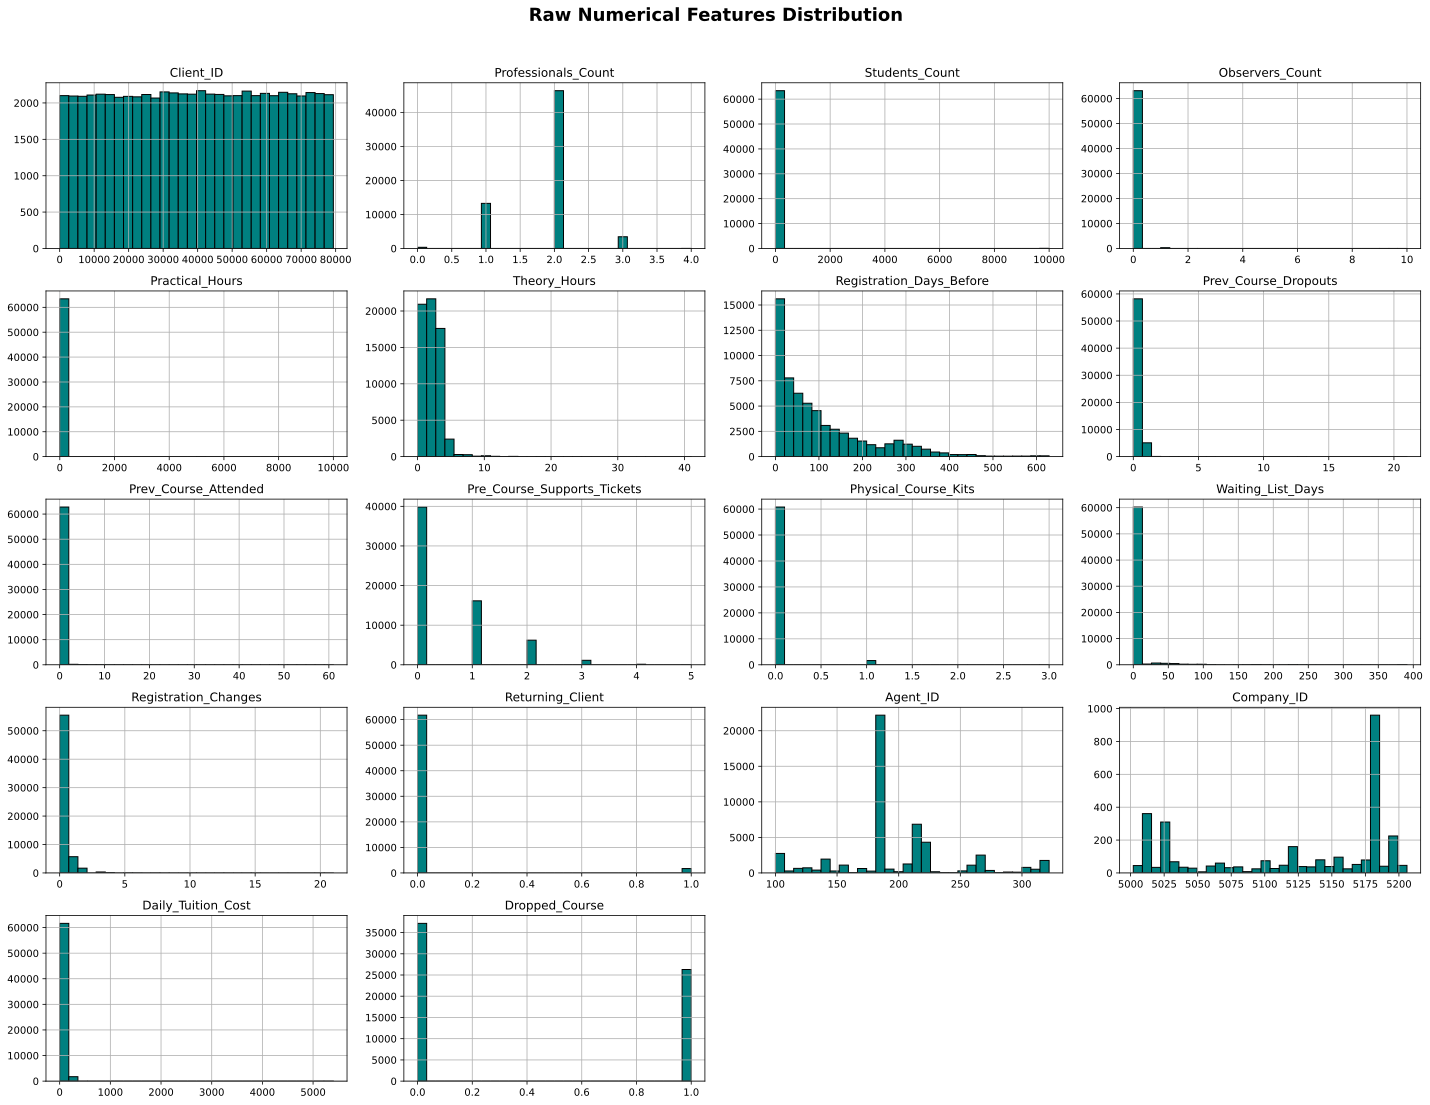


=== Initial Correlation Heatmap ===


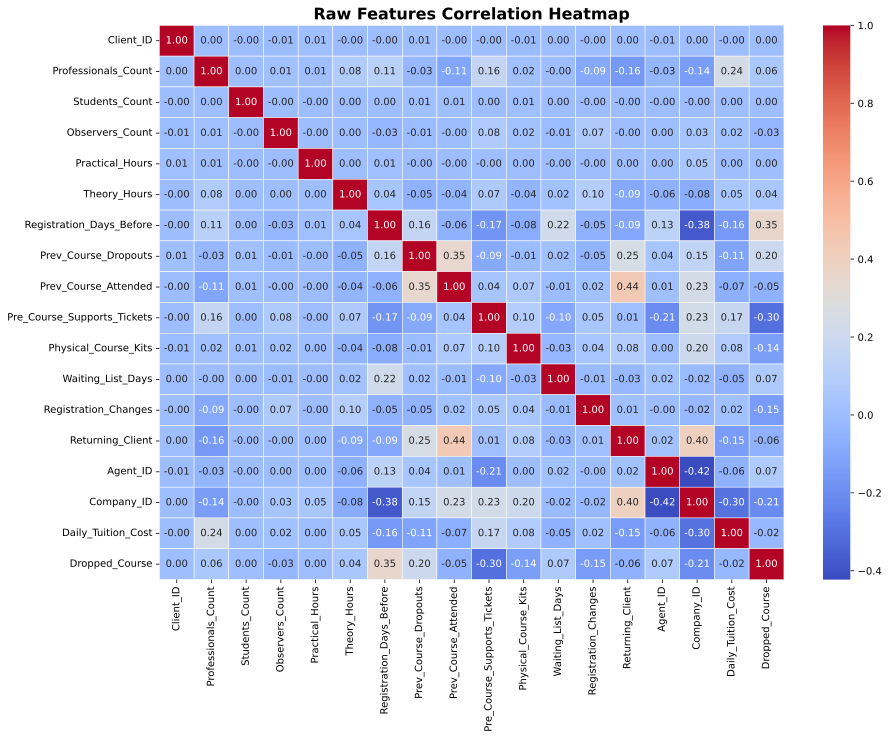

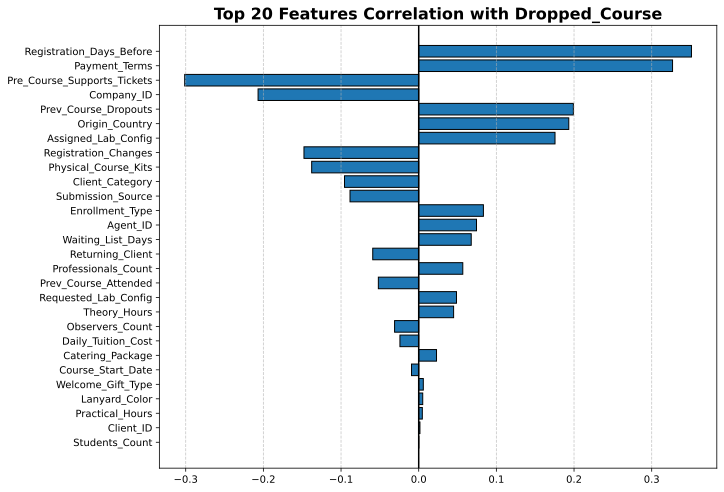

In [4]:
# =========================================================
# --- Data Dictionary (Initial Overview) ---
# =========================================================
summary_df = pd.DataFrame({
    'Data_Type': df.dtypes,
    'Total_Nulls': df.isnull().sum(),
    'Null_Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique_Values': df.nunique(),
    'Most_Frequent': df.mode().iloc[0],
    'Zero_Count': (df == 0).sum(),
})

print("=== Data Info ===")
print(summary_df.to_string())

text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    print(f"\n--- Column: {col} ---")
    print(df[col].value_counts().head(30))

print("\n=== Descriptive Statistics (Spotting Min/Max Anomalies) ===")
# כאן נראה שהמקסימום של סטודנטים הוא 9999 ושעות מעשיות הוא 10000
display(df.describe())

print("\n=== Numerical Features Distribution ===")
# ההיסטוגרמות יראו מעוכות בגלל החריגים, מה שמצדיק את הטיפול בהם
df.hist(bins=30, figsize=(20, 15), color='teal', edgecolor='black')
plt.suptitle(
    'Raw Numerical Features Distribution', fontsize=18, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print("\n=== Initial Correlation Heatmap ===")
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Raw Features Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()


# קידוד זמני של קטגוריות למספרים רק לצורך מציאת קורלציות ראשוניות
temp_df = df.copy()
for col in temp_df.select_dtypes(include=['object']).columns:
    temp_df[col] = temp_df[col].astype('category').cat.codes

correlations = temp_df.corr()['Dropped_Course'].drop('Dropped_Course')
importance_df = pd.DataFrame({'Correlation': correlations})
importance_df['Abs'] = importance_df['Correlation'].abs()

# בחירת ה-20 המשפיעים ביותר
plot_data = (
    importance_df
    .dropna()
    .sort_values(by='Abs', ascending=False)
    .head(30)
    .sort_values(by='Abs', ascending=True)
)

# צביעה: אדום לקורלציה חיובית (מעלה נשירה), כחול לשלילית (מוריד נשירה)
colors = ['indianred' if val > 0 else 'steelblue' for val in plot_data['Correlation']]

plt.figure(figsize=(10, 8))
plt.barh(plot_data.index, plot_data['Correlation'], edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title(
    'Top 20 Features Correlation with Dropped_Course', fontsize=16, fontweight='bold'
)
plt.show()

In [5]:
# =========================================================
# --- Phase 1: Text Cleaning, Missing Values & Dates ---
# =========================================================
data = df.copy()

# 1. Text Data Cleaning
text_cols = data.select_dtypes(include=['object']).columns
for col in text_cols:
    data[col] = data[col].astype(str).str.lower().str.strip()
    data[col] = data[col].str.replace(r'[^\w\s]', '', regex=True)
    data[col] = data[col].replace({'nan': np.nan, 'unknown': np.nan})

# 2. Dropping heavily missing / irrelevant columns upfront
if 'Company_ID' in data.columns:
    data = data.drop(columns=['Company_ID'])

# 3. Median Imputation for numerical columns
num_cols_with_nulls = data.select_dtypes(exclude=['object']).columns
for col in num_cols_with_nulls:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

text_cols_with_nulls = data.select_dtypes(include=['object']).columns
for col in text_cols_with_nulls:
    if data[col].isnull().sum() > 0:
        mode_value = data[col].mode()[0]  # לקיחת הערך הכי נפוץ
        data[col] = data[col].fillna(mode_value)

# 4. Date Feature Engineering (Converting Date to Numeric)
if 'Course_Start_Date' in data.columns:
    data['Course_Start_Date'] = pd.to_datetime(
        data['Course_Start_Date'], errors='coerce'
    )
    data['Start_Day'] = data['Course_Start_Date'].dt.day
    data['Start_Month'] = data['Course_Start_Date'].dt.month
    data['Start_Year'] = data['Course_Start_Date'].dt.year
    data = data.drop(columns=['Course_Start_Date'])

print(f"Data shape after Phase 1: {data.shape}")

Data shape after Phase 1: (63464, 30)


,Practical_Hours,Theory_Hours,Students_Count,Daily_Tuition_Cost,Registration_Days_Before,Registration_Changes
count,63464.000000,63464.000000,63464.000000,63464.000000,63464.000000,63464.000000
mean,0.782475,2.148588,0.085702,98.753327,91.283736,0.171231
std,0.887119,1.361040,0.360832,36.123898,90.032586,0.515218
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,75.000000,21.000000,0.000000
50%,1.000000,2.000000,0.000000,94.500000,65.000000,0.000000
75%,1.000000,3.000000,0.000000,117.000000,131.000000,0.000000
max,14.000000,15.000000,3.000000,375.500000,365.000000,5.000000


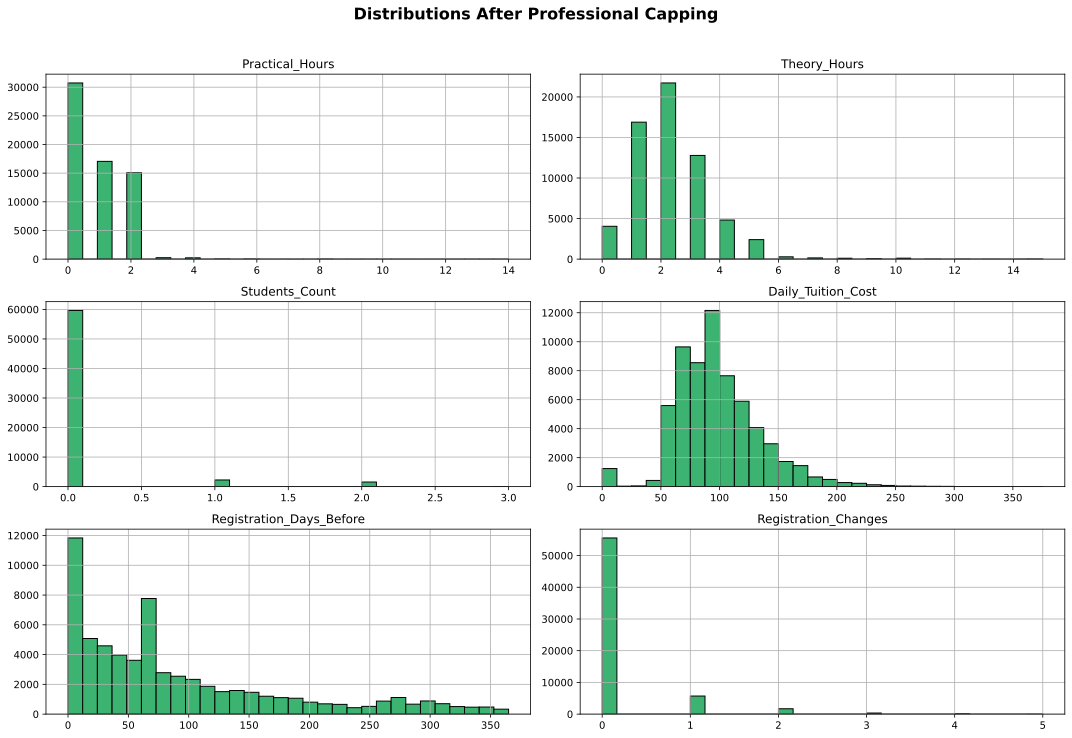

In [6]:
# =========================================================
# --- Phase 2: Outlier Treatment (Windsorization / Capping) ---
# =========================================================
data['Practical_Hours'] = data['Practical_Hours'].apply(
    lambda x: 0 if x < 0 else (data['Practical_Hours'].median() if x > 15 else x)
)
data['Theory_Hours'] = data['Theory_Hours'].apply(
    lambda x: data['Theory_Hours'].median() if x > 15 else x
)
data['Students_Count'] = data['Students_Count'].replace(
    9999, data['Students_Count'].median()
)
data['Students_Count'] = data['Students_Count'].apply(
    lambda x: data['Students_Count'].median() if x > 5 else x
)
data['Daily_Tuition_Cost'] = data['Daily_Tuition_Cost'].apply(
    lambda x: data['Daily_Tuition_Cost'].median() if x > 400 else x
)
data['Registration_Changes'] = data['Registration_Changes'].apply(
    lambda x: data['Registration_Changes'].median() if x > 5 else x
)
if 'Registration_Days_Before' in data.columns:
    data['Registration_Days_Before'] = data['Registration_Days_Before'].apply(
        lambda x: data['Registration_Days_Before'].median() if x > 365 else x
    )
if 'Waiting_List_Days' in data.columns:
    data['Was_On_Waiting_List'] = data['Waiting_List_Days'].apply(
        lambda x: 1 if x > 0 else 0
    )
    data = data.drop(columns=['Waiting_List_Days'], errors='ignore')

# =========================================================
# --- Display Results ---
# =========================================================
cols_to_check = [
    'Practical_Hours',
    'Theory_Hours',
    'Students_Count',
    'Daily_Tuition_Cost',
    'Registration_Days_Before',
    'Registration_Changes',
]
cols_to_check = [col for col in cols_to_check if col in data.columns]
display(data[cols_to_check].describe())

data[cols_to_check].hist(
    bins=30, figsize=(15, 10), color='mediumseagreen', edgecolor='black'
)
plt.suptitle(
    'Distributions After Professional Capping', fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

=== Impact of Data Cleaning & Outlier Treatment ===


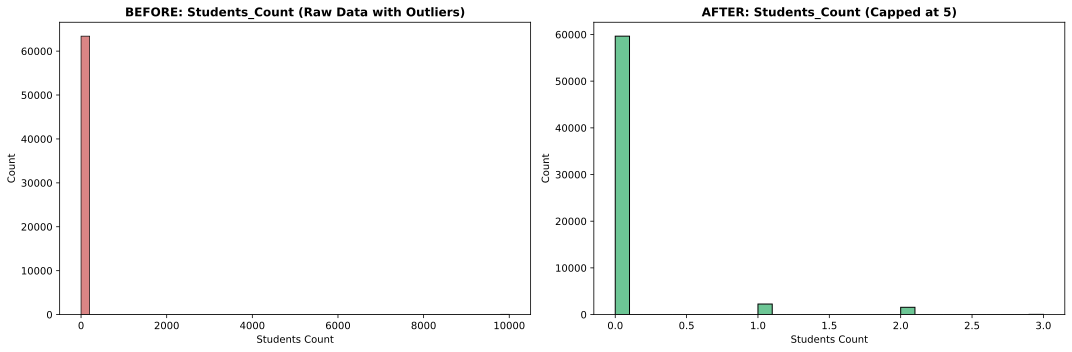

In [7]:
print("=== Impact of Data Cleaning & Outlier Treatment ===")

# ניקח את כמות הסטודנטים כדוגמה קלאסית לחריגים (היה שם 9999)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# גרף 1: לפני הטיפול (מתוך ה-df המקורי)
sns.histplot(df['Students_Count'].dropna(), bins=50, color='indianred', ax=axes[0])
axes[0].set_title('BEFORE: Students_Count (Raw Data with Outliers)', fontweight='bold')
axes[0].set_xlabel('Students Count')

# גרף 2: אחרי הטיפול ב-Capping (מתוך ה-data הנקי)
sns.histplot(data['Students_Count'], bins=30, color='mediumseagreen', ax=axes[1])
axes[1].set_title('AFTER: Students_Count (Capped at 5)', fontweight='bold')
axes[1].set_xlabel('Students Count')

plt.tight_layout()
plt.show()

In [8]:
# =========================================================
# --- Sanity Check: Verifying Data After Cleaning ---
# =========================================================
summary_data = pd.DataFrame({
    'Data_Type': data.dtypes,
    'Total_Nulls': data.isnull().sum(),
    'Null_Percentage (%)': (data.isnull().sum() / len(data) * 100).round(2),
    'Unique_Values': data.nunique(),
    'Most_Frequent': data.mode().iloc[0],
    'Zero_Count': (data == 0).sum(),
})

print("=== Data Info ===")
print(summary_data.to_string())

# מעדכנים את רשימת העמודות הטקסטואליות לאחר הניקוי
text_cols_updated = data.select_dtypes(include=['object']).columns

for col in text_cols_updated:
    if col in data.columns:  # מוודאים שהעמודה עדיין קיימת
        print(f"\n--- Column: {col} ---")
        print(data[col].value_counts().head(20))

=== Data Info ===
                            Data_Type  Total_Nulls  Null_Percentage (%)  Unique_Values             Most_Frequent  Zero_Count
Client_ID                       int64            0                  0.0          63464                         1           0
Professionals_Count             int64            0                  0.0              5                       2.0         338
Students_Count                float64            0                  0.0              4                       0.0       59637
Observers_Count                 int64            0                  0.0              5                       0.0       63149
Practical_Hours               float64            0                  0.0             13                       0.0       30736
Theory_Hours                  float64            0                  0.0             16                       2.0        4045
Registration_Days_Before      float64            0                  0.0            362                     

=== Target Variable Distribution (Dropped_Course) ===
Course Completed (0): 58.56%
Course Dropped (1): 41.44%

=== Global Numerical Correlation Heatmap ===


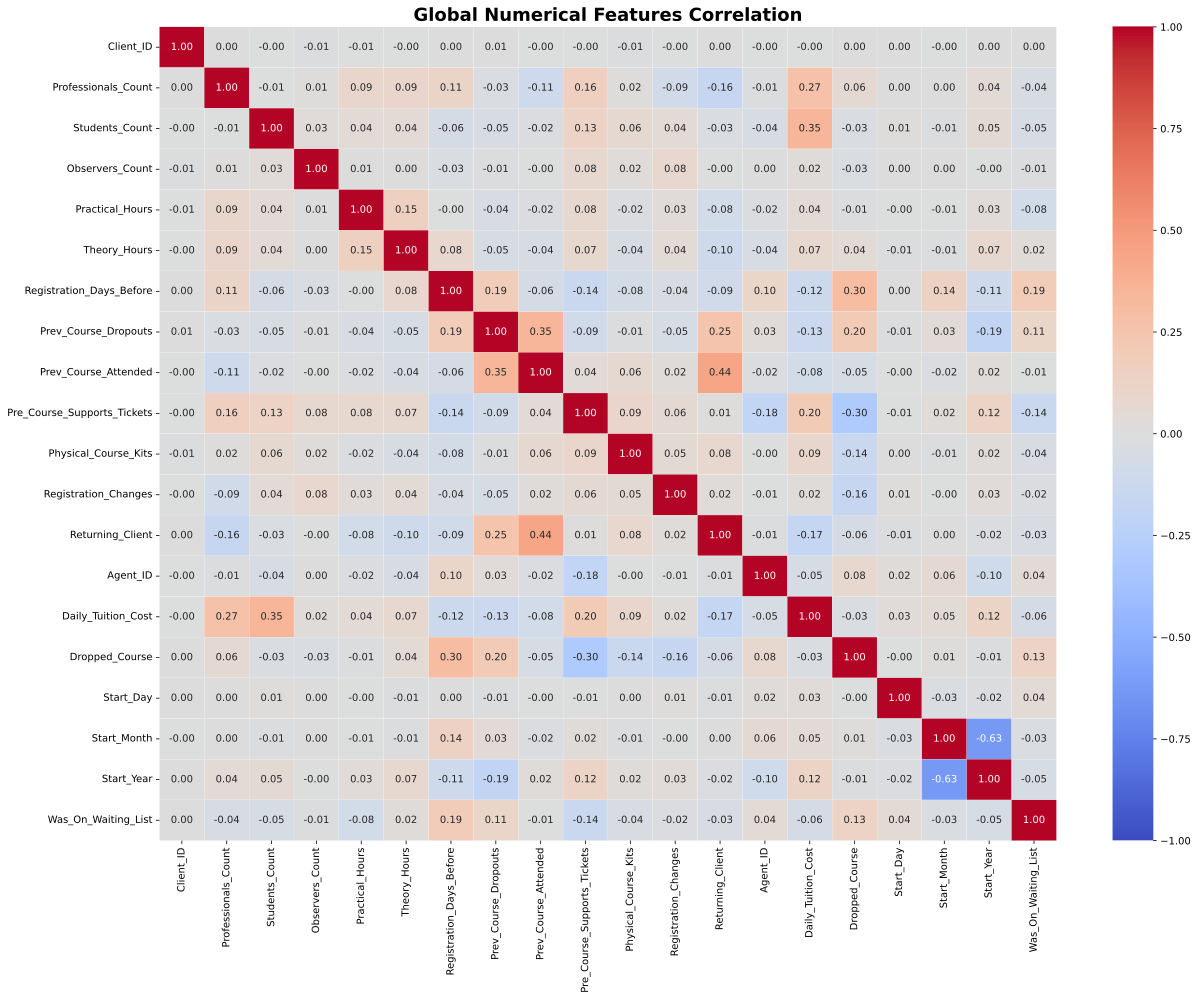


=== Global Feature Importance===


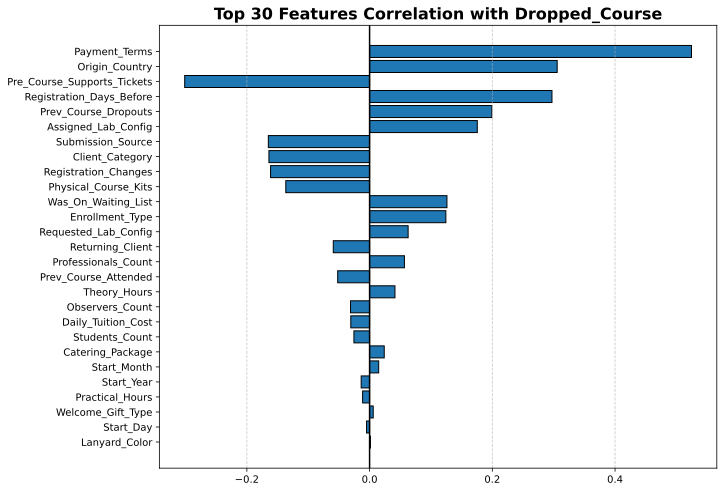

In [9]:
# =========================================================
# --- Target Variable Analysis & Feature Correlation ---
# =========================================================
print("=== Target Variable Distribution (Dropped_Course) ===")
# הדפסת אחוז הנושרים מול הנשארים
dist = data['Dropped_Course'].value_counts(normalize=True).round(4) * 100
print(f"Course Completed (0): {dist.get(0, 0)}%")
print(f"Course Dropped (1): {dist.get(1, 0)}%")

# וידוא שהמטרה היא מספר שלם (0 או 1)
data['Dropped_Course'] = data['Dropped_Course'].astype(int)

print("\n=== Global Numerical Correlation Heatmap ===")
numeric_only = data.select_dtypes(include=['number'])

# הגדלנו את הבד כדי לתת למשבצות כמה שיותר מקום (18 על 14)
plt.figure(figsize=(18, 14))

# כאן הקסם: annot=True מחזיר את המספרים, ו-annot_kws מכווץ אותם!
sns.heatmap(
    numeric_only.corr(),
    annot=True,
    annot_kws={"size": 10},  # גודל פונט קטן (אפשר לשנות ל-6 או 8 לפי הטעם)
    fmt=".2f",  # שתי ספרות אחרי הנקודה (אפשר לשנות ל-".1f" כדי לחסוך עוד מקום)
    cmap='coolwarm',
    linewidths=0.1,
    vmin=-1,
    vmax=1,
)

plt.title('Global Numerical Features Correlation', fontsize=18, fontweight='bold')
plt.tight_layout()  # הפקודה הזו מוודאת שהטקסטים בצדדים לא ייחתכו
plt.show()

print("\n=== Global Feature Importance===")
analysis_data = data.copy()
cols_to_drop_for_analysis = ['Client_ID', 'Agent_ID']
analysis_data = analysis_data.drop(
    columns=[col for col in cols_to_drop_for_analysis if col in analysis_data.columns],
    errors='ignore',
)

# קידוד זמני של קטגוריות למספרים רק לצורך מציאת קורלציות ראשוניות
for col in analysis_data.select_dtypes(include=['object']).columns:
    analysis_data[col] = analysis_data[col].astype('category').cat.codes

# חישוב קורלציות מול משתנה המטרה
correlations = analysis_data.corr()['Dropped_Course'].drop('Dropped_Course')
importance_df = pd.DataFrame({'Correlation': correlations})
importance_df['Abs'] = importance_df['Correlation'].abs()

# בחירת ה-20 המשפיעים ביותר
plot_data = (
    importance_df
    .dropna()
    .sort_values(by='Abs', ascending=False)
    .head(30)
    .sort_values(by='Abs', ascending=True)
)

# צביעה: אדום לקורלציה חיובית (מעלה נשירה), כחול לשלילית (מוריד נשירה)
colors = ['indianred' if val > 0 else 'steelblue' for val in plot_data['Correlation']]

plt.figure(figsize=(10, 8))
plt.barh(plot_data.index, plot_data['Correlation'], edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title(
    'Top 30 Features Correlation with Dropped_Course', fontsize=16, fontweight='bold'
)
plt.show()

In [10]:
# =========================================================
# --- Final Cleanup Before Categorical Encoding ---
# =========================================================
print("=== Removing Identifiers from the Real Data ===")

cols_to_remove = ['Client_ID', 'Agent_ID']
data = data.drop(
    columns=[col for col in cols_to_remove if col in data.columns], errors='ignore'
)

print(f"Data shape after removing identifiers: {data.shape}")

=== Removing Identifiers from the Real Data ===
Data shape after removing identifiers: (63464, 28)


In [11]:
# =========================================================
# --- Feature Engineering: Categorical Encoding ---
# =========================================================
print("=== Handling High Cardinality & One-Hot Encoding ===")

text_columns = data.select_dtypes(include=['object']).columns

# 1. Baseline: What happens if we encode everything?
data_encoded = pd.get_dummies(data, columns=text_columns, drop_first=True)
print(f"Shape if we encode ALL categories: {data_encoded.shape}")

# 2. Thresholding Strategy (Grouping rare categories into 'other')
# Testing 0.5% Threshold
data_for_dummies = data.copy()
threshold = 0.005
for col in text_columns:
    frequencies = data_for_dummies[col].value_counts(normalize=True)
    small_categories = frequencies[frequencies < threshold].index
    data_for_dummies[col] = data_for_dummies[col].replace(small_categories, 'other')
data_thresholded = pd.get_dummies(
    data_for_dummies, columns=text_columns, drop_first=True
)
print(f"Shape with Threshold (0.005): {data_thresholded.shape}")

# Testing 0.1% Threshold
data_for_dummies1 = data.copy()
threshold1 = 0.001
for col in text_columns:
    frequencies = data_for_dummies1[col].value_counts(normalize=True)
    small_categories = frequencies[frequencies < threshold1].index
    data_for_dummies1[col] = data_for_dummies1[col].replace(small_categories, 'other')
data_thresholded1 = pd.get_dummies(
    data_for_dummies1, columns=text_columns, drop_first=True
)
print(f"Shape with Threshold (0.001: {data_thresholded1.shape}")

=== Handling High Cardinality & One-Hot Encoding ===
Shape if we encode ALL categories: (63464, 212)
Shape with Threshold (0.005): (63464, 73)
Shape with Threshold (0.001: (63464, 96)


The 30 most important features


,Feature,Correlation
0,Payment_Terms_prepaid nonrefundable,0.533218
1,Payment_Terms_pay upon start,-0.528895
2,Origin_Country_prt,0.382651
3,Pre_Course_Supports_Tickets,-0.301284
4,Registration_Days_Before,0.297213
5,Assigned_Lab_Config_standard pc windows,0.199390
6,Prev_Course_Dropouts,0.199148
7,Origin_Country_fra,-0.172123
8,Registration_Changes,-0.161367
9,Assigned_Lab_Config_linux workstation,-0.145501


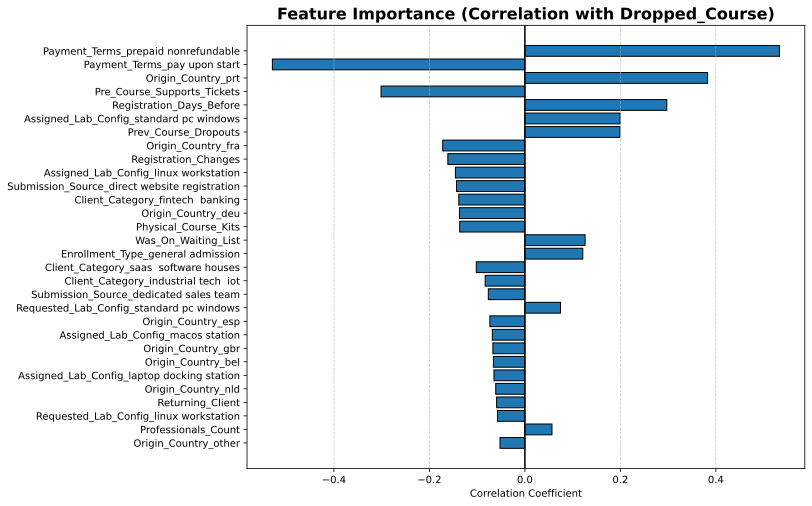

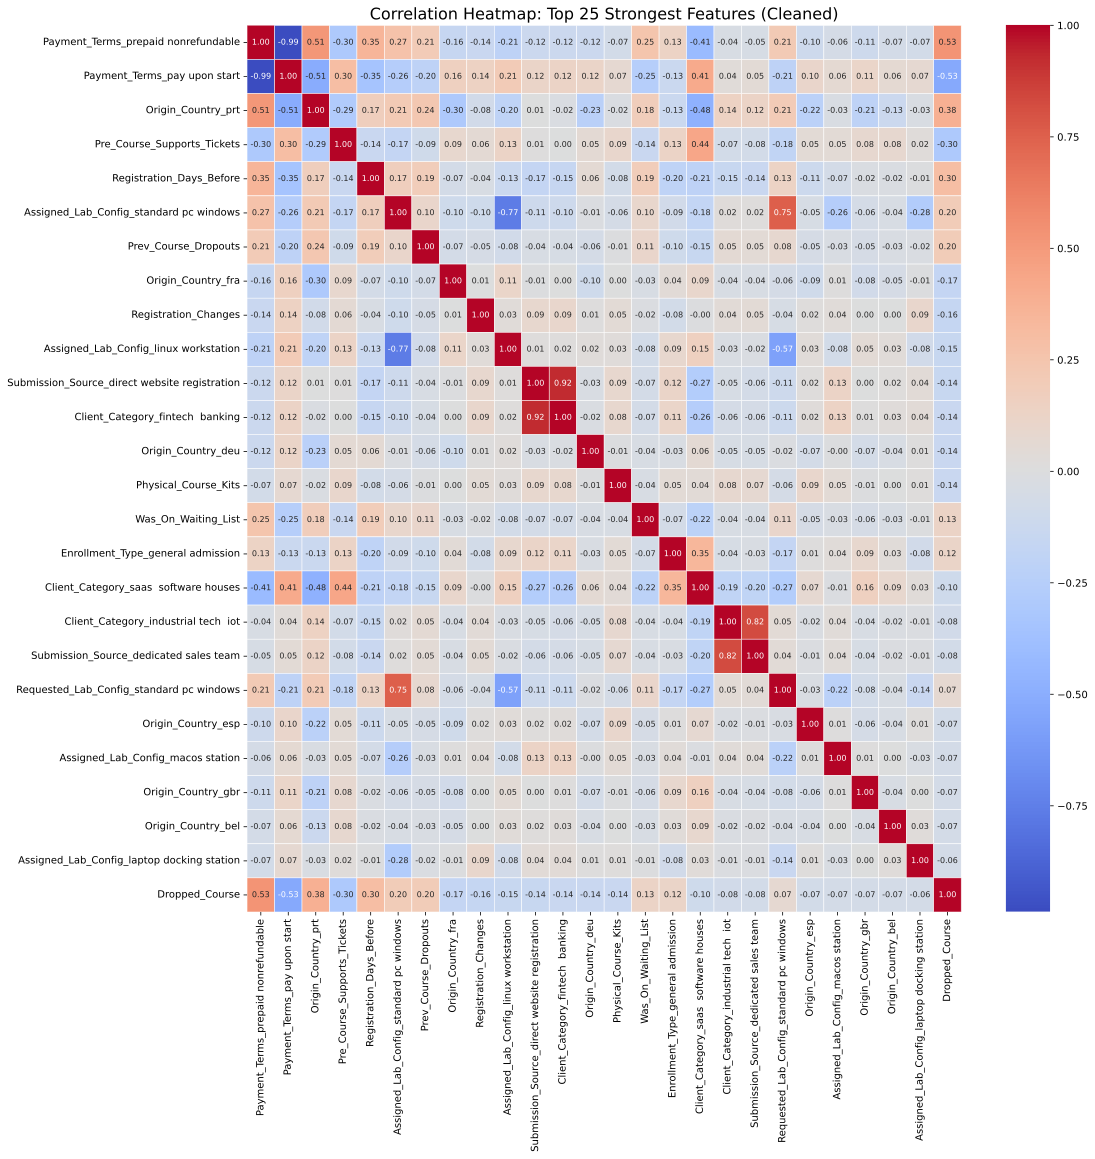

In [12]:
# Addressing the Curse of Dimensionality: Removing identifiers (Client_ID, Agent_ID) that add noise to the model, and displaying a clean heatmap of the top 25 strongest features post-cleaning.
cols_to_keep = [
    col
    for col in data_thresholded.columns
    if not col.startswith('Agent_ID') and not col.startswith('Client_ID')
]
data_clean = data_thresholded[cols_to_keep].copy()

corr_with_target = data_clean.corr()['Dropped_Course'].drop('Dropped_Course')

importance_df = pd.DataFrame({
    'Feature': corr_with_target.index,
    'Correlation': corr_with_target.values,
    'Absolute_Impact': corr_with_target.abs().values,
})

importance_df = importance_df.sort_values(
    by='Absolute_Impact', ascending=False
).reset_index(drop=True)

display_df = importance_df[['Feature', 'Correlation']]

print("The 30 most important features")
display(display_df.head(30))

plt.figure(figsize=(10, 8))
top_30_plot = importance_df.head(30).sort_values(by='Absolute_Impact', ascending=True)
plt.barh(top_30_plot['Feature'], top_30_plot['Correlation'], edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.5)
plt.title(
    'Feature Importance (Correlation with Dropped_Course)',
    fontsize=16,
    fontweight='bold',
)
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


top_25_names = importance_df.head(25)['Feature'].tolist()
df_heatmap = data_clean[top_25_names + ['Dropped_Course']]

plt.figure(figsize=(16, 16))
sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8},
)
plt.title('Correlation Heatmap: Top 25 Strongest Features (Cleaned)', fontsize=16)
plt.show()


In [13]:
del data_encoded
del data_for_dummies
del data_for_dummies1
del data_thresholded
del data_thresholded1

In [14]:
# Splitting the data into Train and Validation sets while preserving the target proportion (Stratify), and scaling numerical data (StandardScaler) in preparation for modeling.
X = data_clean.drop(columns=['Dropped_Course'])
y = data_clean['Dropped_Course']
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Size of Train Data: {X_train.shape}")
print(f"Size of Validation Data: {X_validation.shape}\n")
print("Dropped presentage on train data:")
print(y_train.value_counts(normalize=True))
print("\nDropped presentage on validation data:")
print(y_validation.value_counts(normalize=True))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

print(f"\nScaled Train shape: {X_train_scaled.shape}")
print(f"Scaled Validation shape: {X_validation_scaled.shape}")

Size of Train Data: (50771, 72)
Size of Validation Data: (12693, 72)

Dropped presentage on train data:
Dropped_Course
0    0.58561
1    0.41439
Name: proportion, dtype: float64

Dropped presentage on validation data:
Dropped_Course
0    0.585598
1    0.414402
Name: proportion, dtype: float64

Scaled Train shape: (50771, 72)
Scaled Validation shape: (12693, 72)


Logistic Regression


In [15]:
# Hyperparameter tuning for the baseline Logistic Regression using GridSearchCV to find the optimal regularization parameter (C) that maximizes the ROC-AUC score.
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2']}

base_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
grid_search = GridSearchCV(
    estimator=base_lr, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)

print("Searching for the best parameters. This might take a few seconds...")
grid_search.fit(X_train_scaled, y_train)
best_lr_model = grid_search.best_estimator_
y_pred_proba_best_lr = best_lr_model.predict_proba(X_validation_scaled)[:, 1]
final_auc = roc_auc_score(y_validation, y_pred_proba_best_lr)

print("\n=== Grid Search Results ===")
print(f"Best Parameter (C): {grid_search.best_params_}")
print(f"Best internal Train AUC: {grid_search.best_score_:.4f}")
print(f"Validation AUC Score with best C: {final_auc:.4f}")

Searching for the best parameters. This might take a few seconds...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin


=== Grid Search Results ===
Best Parameter (C): {'C': 100, 'penalty': 'l2'}
Best internal Train AUC: 0.8960
Validation AUC Score with best C: 0.8987


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
# Training and evaluating the final Logistic Regression model using the optimized parameters. Outputting standard classification metrics and AUC scores.
model_lr = LogisticRegression(
    C=100, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42
)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_validation_scaled)
y_prob_train_lr = model_lr.predict_proba(X_train_scaled)[:, 1]
y_prob_val_lr = model_lr.predict_proba(X_validation_scaled)[:, 1]

print("=== Logistic Regression Baseline Results ===")
print("Classification Report (Validation):")
print(classification_report(y_validation, y_pred_lr))
print(f"Train AUC Score:      {roc_auc_score(y_train, y_prob_train_lr):.4f}")
print(f"Validation AUC Score: {roc_auc_score(y_validation, y_prob_val_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_validation, y_prob_val_lr):.4f}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== Logistic Regression Baseline Results ===
Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      7433
           1       0.79      0.76      0.77      5260

    accuracy                           0.82     12693
   macro avg       0.81      0.81      0.81     12693
weighted avg       0.82      0.82      0.82     12693

Train AUC Score:      0.8970
Validation AUC Score: 0.8987
ROC-AUC Score: 0.8987


MLP Model


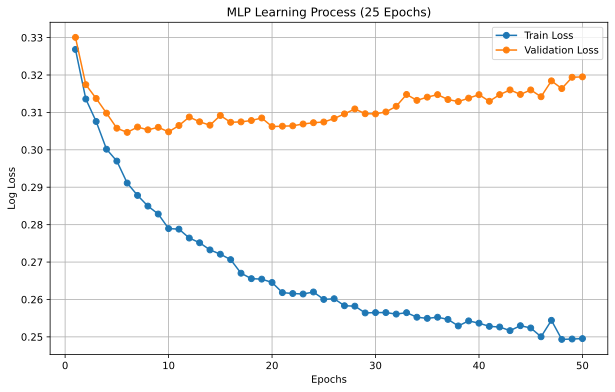

In [17]:
# Visualizing the learning process (Learning Curve) of the Multi-Layer Perceptron (MLP) across 50 epochs to monitor Train vs. Validation log-loss and check for overfitting.
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    random_state=42,
)

train_losses = []
val_losses = []
epochs = 50
classes = np.unique(y_train)

for i in range(epochs):
    mlp.partial_fit(X_train_scaled, y_train, classes=classes)
    train_loss = log_loss(y_train, mlp.predict_proba(X_train_scaled))
    val_loss = log_loss(y_validation, mlp.predict_proba(X_validation_scaled))
    train_losses.append(train_loss)
    val_losses.append(val_loss)

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.title('MLP Learning Process (25 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Training and evaluating the final MLP Classifier using the chosen architecture and early stopping mechanism to prevent overfitting.
model_mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    activation='relu',
    solver='adam',
    random_state=42,
)

model_mlp.fit(X_train_scaled, y_train)

y_pred_mlp = model_mlp.predict(X_validation_scaled)
y_prob_train_mlp = model_mlp.predict_proba(X_train_scaled)[:, 1]
y_prob_val_mlp = model_mlp.predict_proba(X_validation_scaled)[:, 1]

print("=== MLP Classifier Results ===")
print(f"(Stopped after {model_mlp.n_iter_} iterations)")
print("Classification Report (Validation):")
print(classification_report(y_validation, y_pred_mlp))
print(f"Train AUC Score:      {roc_auc_score(y_train, y_prob_train_mlp):.4f}")
print(f"Validation AUC Score: {roc_auc_score(y_validation, y_prob_val_mlp):.4f}")
print(f"Number of iterations: {model_mlp.n_iter_}")
print(f"ROC-AUC Score: {roc_auc_score(y_validation, y_prob_val_mlp):.4f}")

=== MLP Classifier Results ===
(Stopped after 39 iterations)
Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      7433
           1       0.86      0.79      0.82      5260

    accuracy                           0.86     12693
   macro avg       0.86      0.85      0.85     12693
weighted avg       0.86      0.86      0.86     12693

Train AUC Score:      0.9469
Validation AUC Score: 0.9333
Number of iterations: 39
ROC-AUC Score: 0.9333


Random Forest


In [19]:
# Hyperparameter tuning for the Random Forest model using GridSearchCV. Comparing different tree depths, estimators, and split criteria to find the most robust configuration.
param_grid = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'max_depth': [15, 20, 25, 35],
    'min_samples_split': [2, 5, 10],
}

base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

print("Running Grid Search Comparison (No final model training)...")
grid_search.fit(X_train_scaled, y_train)
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[
    [
        'param_max_depth',
        'param_n_estimators',
        'param_min_samples_split',
        'mean_train_score',
        'mean_test_score',
    ]
].copy()
results_df.columns = [
    'Max_Depth',
    'Trees',
    'Min_Samples_Split',
    'Train_AUC',
    'Validation_AUC',
]
results_df = results_df.sort_values(by='Validation_AUC', ascending=False)

print("=== Compare Table ===")
print(results_df.head(50).to_string(index=False))

Running Grid Search Comparison (No final model training)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

In [ ]:
# Training and evaluating the optimized Random Forest Classifier, which inherently handles non-linear relationships and balances classes well.
model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
)

model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_validation_scaled)
y_prob_train_rf = model_rf.predict_proba(X_train_scaled)[:, 1]
y_prob_val_rf = model_rf.predict_proba(X_validation_scaled)[:, 1]

print("=== Optimized Random Forest Results ===")
print("Classification Report (Validation):")
print(classification_report(y_validation, y_pred_rf))
print(f"Train AUC Score:      {roc_auc_score(y_train, y_prob_train_rf):.4f}")
print(f"Validation AUC Score: {roc_auc_score(y_validation, y_prob_val_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_validation, y_prob_val_rf):.4f}")

=== Optimized Random Forest Results ===
Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7433
           1       0.89      0.82      0.85      5260

    accuracy                           0.88     12693
   macro avg       0.88      0.88      0.88     12693
weighted avg       0.88      0.88      0.88     12693

Train AUC Score:      0.9876
Validation AUC Score: 0.9542
ROC-AUC Score: 0.9542


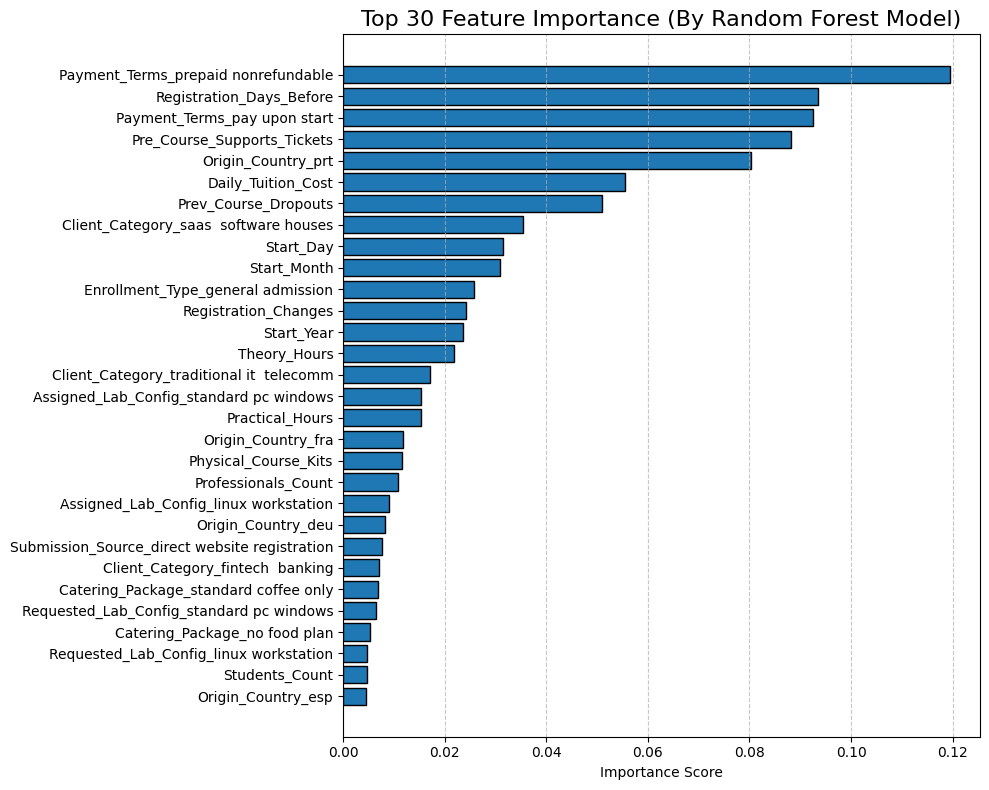

In [ ]:
# Extracting and visualizing the built-in Feature Importance from the Random Forest model (based on Gini impurity) to understand which variables drive the predictions.
feature_names = X_train.columns
importances = model_rf.feature_importances_
feature_imp = pd.Series(model_rf.feature_importances_, index=X_train.columns)
top_30_features = feature_imp.nlargest(30).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_30_features.index, top_30_features.values, edgecolor='black')
plt.title('Top 30 Feature Importance (By Random Forest Model)', fontsize=16)
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Boosting


In [ ]:
# Hyperparameter tuning for the HistGradientBoosting model using RandomizedSearchCV (for computational efficiency), exploring learning rates and tree limits.
gb_model_check = HistGradientBoostingClassifier(random_state=42)
params = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
}

search = RandomizedSearchCV(
    gb_model_check,
    params,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
)

search.fit(X_train_scaled, y_train)
results_df = pd.DataFrame(search.cv_results_)
comparison_table = results_df[['params', 'mean_train_score', 'mean_test_score']]
comparison_table.columns = ['Parameters', 'Train AUC', 'Validation AUC']
sorted_table = comparison_table.sort_values(by='Validation AUC', ascending=False)

print("--- Parameter comparison ---")
print(sorted_table.to_string())

--- Parameter comparison ---
                                                   Parameters  Train AUC  Validation AUC
0  {'max_iter': 300, 'max_depth': None, 'learning_rate': 0.2}   0.978148        0.947633
5    {'max_iter': 200, 'max_depth': 10, 'learning_rate': 0.2}   0.978933        0.947216
3    {'max_iter': 100, 'max_depth': 10, 'learning_rate': 0.2}   0.970064        0.946325
9     {'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.1}   0.963824        0.944860
6  {'max_iter': 100, 'max_depth': None, 'learning_rate': 0.1}   0.957952        0.943821
4     {'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.1}   0.955396        0.941731
2     {'max_iter': 300, 'max_depth': 3, 'learning_rate': 0.2}   0.949614        0.939937
8   {'max_iter': 300, 'max_depth': 10, 'learning_rate': 0.01}   0.938556        0.933448
1     {'max_iter': 200, 'max_depth': 3, 'learning_rate': 0.1}   0.935627        0.930714
7     {'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.1}   0.925471        0

In [ ]:
# Training and evaluating the final HistGradientBoosting Classifier, a highly efficient gradient boosting implementation suitable for complex data structures.
model_gb = HistGradientBoostingClassifier(
    max_iter=200, max_depth=10, learning_rate=0.2, random_state=42
)
model_gb.fit(X_train_scaled, y_train)

y_pred_gb = model_gb.predict(X_validation_scaled)
y_prob_train_gb = model_gb.predict_proba(X_train_scaled)[:, 1]
y_prob_val_gb = model_gb.predict_proba(X_validation_scaled)[:, 1]

print("=== HistGradientBoosting Results ===")
print("Classification Report (Validation):")
print(classification_report(y_validation, y_pred_gb))
print(f"Train AUC Score:      {roc_auc_score(y_train, y_prob_train_gb):.4f}")
print(f"Validation AUC Score: {roc_auc_score(y_validation, y_prob_val_gb):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_validation, y_prob_val_gb):.4f}")

=== HistGradientBoosting Results ===
Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      7433
           1       0.88      0.82      0.85      5260

    accuracy                           0.88     12693
   macro avg       0.88      0.87      0.88     12693
weighted avg       0.88      0.88      0.88     12693

Train AUC Score:      0.9714
Validation AUC Score: 0.9517
ROC-AUC Score: 0.9517


Models Analysis


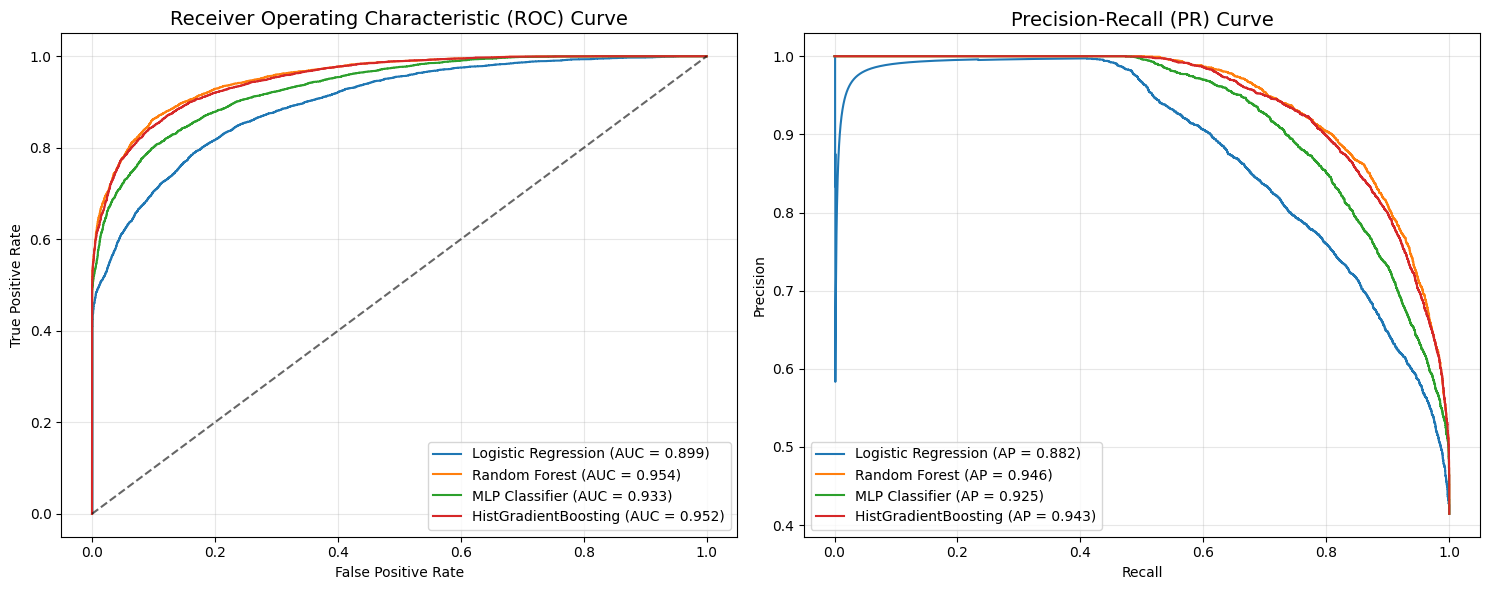

Top Feature Differences between 'Missed' Dropouts and 'Caught' Dropouts:


,False Negatives Mean (Missed),True Positives Mean (Caught),Difference
Payment_Terms_prepaid nonrefundable,-0.450,0.864,-1.314
Payment_Terms_pay upon start,0.444,-0.858,1.302
Pre_Course_Supports_Tickets,0.512,-0.550,1.062
Origin_Country_prt,-0.195,0.592,-0.786
Client_Category_saas software houses,0.512,-0.238,0.750
Registration_Days_Before,-0.242,0.464,-0.706
Prev_Course_Dropouts,-0.204,0.348,-0.552
Assigned_Lab_Config_standard pc windows,-0.175,0.319,-0.494
Client_Category_traditional it telecomm,-0.398,0.082,-0.480
Requested_Lab_Config_standard pc windows,-0.306,0.165,-0.471


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
for y_prob, name in zip(
    [y_prob_val_lr, y_prob_val_rf, y_prob_val_mlp, y_prob_val_gb],
    ['Logistic Regression', 'Random Forest', 'MLP Classifier', 'HistGradientBoosting'],
):
    fpr, tpr, _ = roc_curve(y_validation, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
for y_prob, name in zip(
    [y_prob_val_lr, y_prob_val_rf, y_prob_val_mlp, y_prob_val_gb],
    ['Logistic Regression', 'Random Forest', 'MLP Classifier', 'HistGradientBoosting'],
):
    precision, recall, _ = precision_recall_curve(y_validation, y_prob)
    ap = average_precision_score(y_validation, y_prob)
    axes[1].plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

axes[1].set_title('Precision-Recall (PR) Curve', fontsize=14)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

df_val_scaled = pd.DataFrame(X_validation_scaled, columns=X_train.columns)
fn_mask = (y_validation.values == 1) & (y_pred_rf == 0)
tp_mask = (y_validation.values == 1) & (y_pred_rf == 1)
fn_df = df_val_scaled[fn_mask]
tp_df = df_val_scaled[tp_mask]

error_comparison = pd.DataFrame({
    'False Negatives Mean (Missed)': fn_df.mean(),
    'True Positives Mean (Caught)': tp_df.mean(),
})
error_comparison['Difference'] = (
    error_comparison['False Negatives Mean (Missed)']
    - error_comparison['True Positives Mean (Caught)']
)

print("Top Feature Differences between 'Missed' Dropouts and 'Caught' Dropouts:")
display(
    error_comparison
    .reindex(error_comparison['Difference'].abs().sort_values(ascending=False).index)
    .head(10)
    .round(3)
)

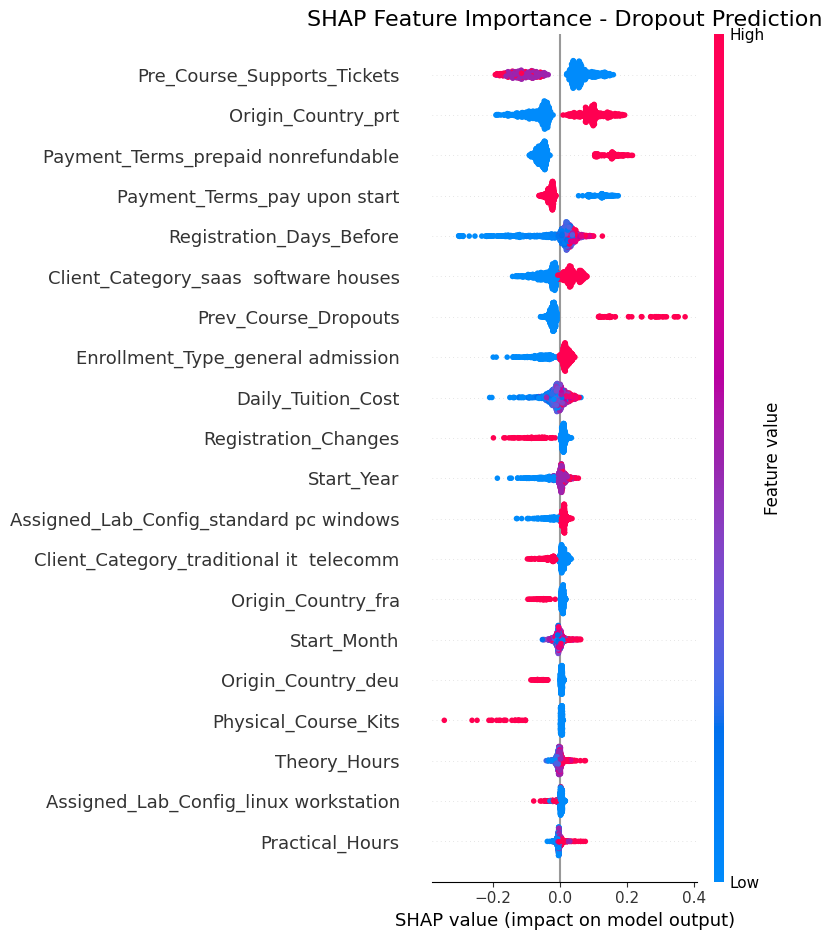

<Figure size 1000x600 with 0 Axes>

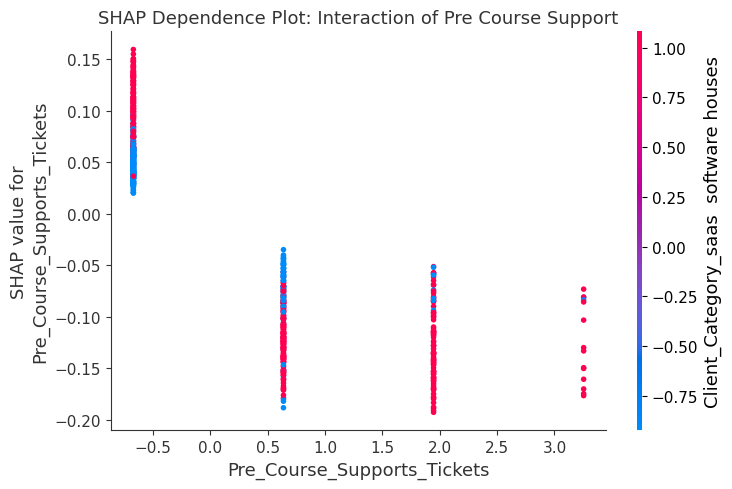

In [ ]:
X_val_sample = pd.DataFrame(X_validation_scaled, columns=X_train.columns).sample(
    1000, random_state=42
)
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_val_sample)
if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_values_class_1 = shap_values[:, :, 1]
else:
    shap_values_class_1 = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_class_1, X_val_sample, show=False)
plt.title("SHAP Feature Importance - Dropout Prediction", fontsize=16)
plt.tight_layout()
plt.show()

# SHAP Dependence Plot for the most important feature
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "Pre_Course_Supports_Tickets",
    shap_values_class_1,
    X_val_sample,
    show=False,
    title="SHAP Dependence Plot: Interaction of Pre Course Support",
)
plt.tight_layout()
plt.show()

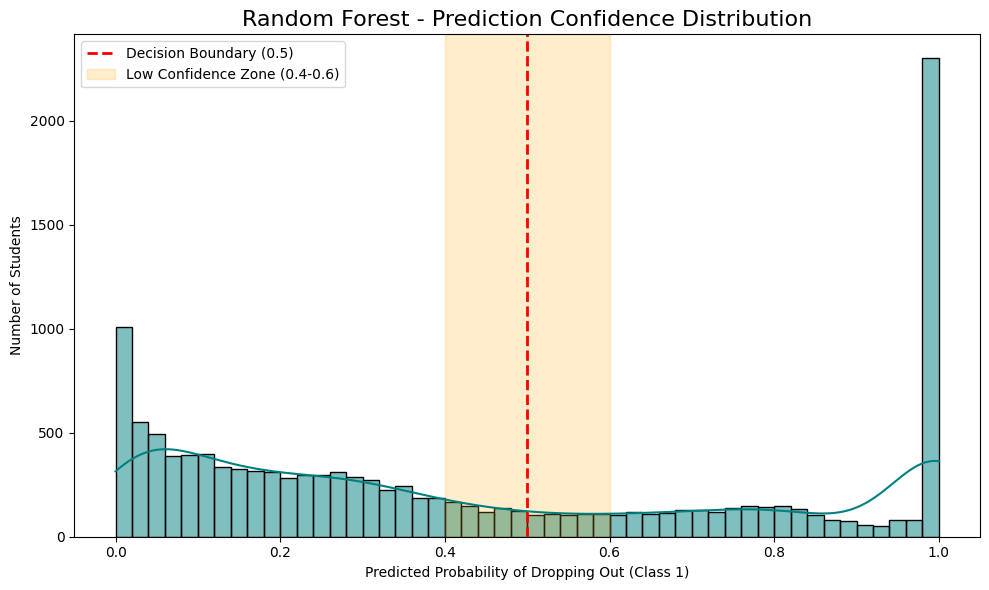

Number of students in the Low Confidence Zone (0.40 - 0.60): 1232


In [ ]:
# Extracting the actual probabilities (confidence) from the Random Forest model
rf_probabilities = model_rf.predict_proba(X_validation_scaled)[:, 1]

plt.figure(figsize=(10, 6))
sns.histplot(rf_probabilities, bins=50, kde=True, color='teal')
plt.axvline(
    0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0.5)'
)
plt.axvspan(
    0.40, 0.60, color='orange', alpha=0.2, label='Low Confidence Zone (0.4-0.6)'
)
plt.title('Random Forest - Prediction Confidence Distribution', fontsize=16)
plt.xlabel('Predicted Probability of Dropping Out (Class 1)')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.show()
uncertain_cases = ((rf_probabilities > 0.40) & (rf_probabilities < 0.60)).sum()
print(f"Number of students in the Low Confidence Zone (0.40 - 0.60): {uncertain_cases}")

Selected random borderline student index: 247


/Users/rondrach/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


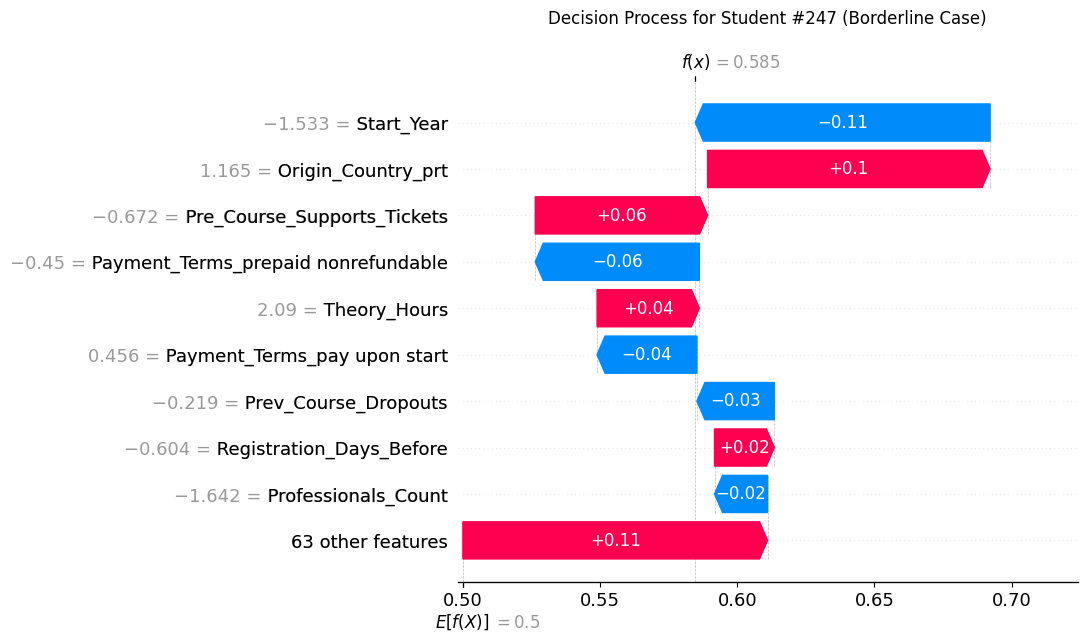

In [ ]:
# Find "interesting" students who are in the uncertain zone (probability around 0.5)
sample_probs = model_rf.predict_proba(X_val_sample)[:, 1]
uncertain_indices = np.where((sample_probs > 0.40) & (sample_probs < 0.60))[0]

if len(uncertain_indices) > 0:
    student_idx = np.random.choice(uncertain_indices)
    print(f"Selected random borderline student index: {student_idx}")
else:
    student_idx = 42
    print("No uncertain students found in the sample, defaulting to index 42.")
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

student_exp = shap.Explanation(
    values=shap_values_class_1[student_idx],
    base_values=base_value,
    data=X_val_sample.iloc[student_idx],
    feature_names=X_val_sample.columns,
)

shap.plots.waterfall(student_exp, max_display=10, show=False)
plt.title(f"Decision Process for Student #{student_idx} (Borderline Case)", pad=20)
plt.show()

In [ ]:
combinations = [
    ("Logistic Regression", [y_prob_val_lr]),
    ("Random Forest", [y_prob_val_rf]),
    ("MLP", [y_prob_val_mlp]),
    ("Gradient Boosting", [y_prob_val_gb]),
    ("Logistic Regression + Random Forest", [y_prob_val_lr, y_prob_val_rf]),
    ("Logistic Regression + MLP", [y_prob_val_lr, y_prob_val_mlp]),
    ("Logistic Regression + Gradient Boosting", [y_prob_val_lr, y_prob_val_gb]),
    ("Random Forest + MLP", [y_prob_val_rf, y_prob_val_mlp]),
    ("Random Forest + Gradient Boosting", [y_prob_val_rf, y_prob_val_gb]),
    ("MLP + Gradient Boosting", [y_prob_val_mlp, y_prob_val_gb]),
    (
        "Logistic Regression + Random Forest + MLP",
        [y_prob_val_lr, y_prob_val_rf, y_prob_val_mlp],
    ),
    (
        "Logistic Regression + Random Forest + Gradient Boosting",
        [y_prob_val_lr, y_prob_val_rf, y_prob_val_gb],
    ),
    (
        "Logistic Regression + MLP + Gradient Boosting",
        [y_prob_val_lr, y_prob_val_mlp, y_prob_val_gb],
    ),
    (
        "Random Forest + MLP + Gradient Boosting",
        [y_prob_val_rf, y_prob_val_mlp, y_prob_val_gb],
    ),
    ("All 4 Models", [y_prob_val_lr, y_prob_val_rf, y_prob_val_mlp, y_prob_val_gb]),
]

results = []
for name, probs in combinations:
    avg_prob = np.mean(probs, axis=0)

    auc = roc_auc_score(y_validation, avg_prob)
    results.append((name, auc))

results.sort(key=lambda x: x[1], reverse=True)
print("AUC Scores for ALL Model Combinations (Validation Set)")
print("-" * 75)
for name, auc in results:
    print(f"AUC: {auc:.4f}  |  Models: {name}")

AUC Scores for ALL Model Combinations (Validation Set)
---------------------------------------------------------------------------
AUC: 0.9550  |  Models: Random Forest + Gradient Boosting
AUC: 0.9542  |  Models: Random Forest
AUC: 0.9524  |  Models: Random Forest + MLP + Gradient Boosting
AUC: 0.9517  |  Models: Gradient Boosting
AUC: 0.9492  |  Models: Logistic Regression + Random Forest + Gradient Boosting
AUC: 0.9488  |  Models: Random Forest + MLP
AUC: 0.9486  |  Models: All 4 Models
AUC: 0.9484  |  Models: MLP + Gradient Boosting
AUC: 0.9434  |  Models: Logistic Regression + Random Forest + MLP
AUC: 0.9432  |  Models: Logistic Regression + MLP + Gradient Boosting
AUC: 0.9416  |  Models: Logistic Regression + Random Forest
AUC: 0.9411  |  Models: Logistic Regression + Gradient Boosting
AUC: 0.9333  |  Models: MLP
AUC: 0.9286  |  Models: Logistic Regression + MLP
AUC: 0.8987  |  Models: Logistic Regression


In [ ]:
val_prob_rf = model_rf.predict_proba(X_validation_scaled)[:, 1]
val_prob_gb = model_gb.predict_proba(X_validation_scaled)[:, 1]

best_w = 0
best_auc = 0

# הלולאה בודקת את כל השילובים מ-0% עד 100% בקפיצות של 1%
for w in np.linspace(0, 1, 101):
    blended_prob = (w * val_prob_gb) + ((1 - w) * val_prob_rf)
    current_auc = roc_auc_score(y_validation, blended_prob)

    if current_auc > best_auc:
        best_auc = current_auc
        best_w = w

print(f"Best Weight for Gradient Boosting: {best_w:.2f} ({(best_w * 100):.0f}%)")
print(f"Best Weight for Random Forest: {1 - best_w:.2f} ({((1 - best_w) * 100):.0f}%)")
print(f"Optimized Validation AUC: {best_auc:.5f}")

Best Weight for Gradient Boosting: 0.31 (31%)
Best Weight for Random Forest: 0.69 (69%)
Optimized Validation AUC: 0.95528


In [ ]:
combinations = [
    ("Logistic Regression", [y_prob_val_lr]),
    ("Random Forest", [y_prob_val_rf]),
    ("MLP", [y_prob_val_mlp]),
    ("Gradient Boosting", [y_prob_val_gb]),
    ("Logistic Regression + Random Forest", [y_prob_val_lr, y_prob_val_rf]),
    ("Logistic Regression + MLP", [y_prob_val_lr, y_prob_val_mlp]),
    ("Logistic Regression + Gradient Boosting", [y_prob_val_lr, y_prob_val_gb]),
    ("Random Forest + MLP", [y_prob_val_rf, y_prob_val_mlp]),
    ("Random Forest + Gradient Boosting", [y_prob_val_rf, y_prob_val_gb]),
    ("MLP + Gradient Boosting", [y_prob_val_mlp, y_prob_val_gb]),
    (
        "Logistic Regression + Random Forest + MLP",
        [y_prob_val_lr, y_prob_val_rf, y_prob_val_mlp],
    ),
    (
        "Logistic Regression + Random Forest + Gradient Boosting",
        [y_prob_val_lr, y_prob_val_rf, y_prob_val_gb],
    ),
    (
        "Logistic Regression + MLP + Gradient Boosting",
        [y_prob_val_lr, y_prob_val_mlp, y_prob_val_gb],
    ),
    (
        "Random Forest + MLP + Gradient Boosting",
        [y_prob_val_rf, y_prob_val_mlp, y_prob_val_gb],
    ),
    ("All 4 Models", [y_prob_val_lr, y_prob_val_rf, y_prob_val_mlp, y_prob_val_gb]),
]

n_iterations = 5000
np.random.seed(42)
results = []

for name, probs in combinations:
    num_models = len(probs)
    if num_models == 1:
        auc = roc_auc_score(y_validation, probs[0])
        results.append((name, auc, [1.0]))
        continue
    best_auc = 0
    best_w = None
    random_weights = np.random.rand(n_iterations, num_models)
    random_weights = random_weights / random_weights.sum(axis=1, keepdims=True)
    for w in random_weights:
        blended_prob = np.zeros_like(probs[0], dtype=float)
        for i in range(num_models):
            blended_prob += w[i] * probs[i]

        current_auc = roc_auc_score(y_validation, blended_prob)
        if current_auc > best_auc:
            best_auc = current_auc
            best_w = w
    results.append((name, best_auc, best_w))
results.sort(key=lambda x: x[1], reverse=True)
print("\nAUC Scores for ALL Model Combinations (Optimized Weights)")
print("-" * 115)
for name, auc, weights in results:
    if name == "All 4 Models":
        m_names = ["LR", "RF", "MLP", "GB"]
    else:
        m_names = (
            name
            .replace("Logistic Regression", "LR")
            .replace("Random Forest", "RF")
            .replace("Gradient Boosting", "GB")
            .split(" + ")
        )
    weight_str = ", ".join([
        f"{m}: {weights[i] * 100:02.0f}%" for i, m in enumerate(m_names)
    ])
    print(f"AUC: {auc:.5f}  |  {name:<55} | Weights: {weight_str}")


AUC Scores for ALL Model Combinations (Optimized Weights)
-------------------------------------------------------------------------------------------------------------------
AUC: 0.95529  |  Random Forest + MLP + Gradient Boosting                 | Weights: RF: 66%, MLP: 01%, GB: 33%
AUC: 0.95529  |  Random Forest + Gradient Boosting                       | Weights: RF: 70%, GB: 30%
AUC: 0.95528  |  Logistic Regression + Random Forest + Gradient Boosting | Weights: LR: 00%, RF: 67%, GB: 33%
AUC: 0.95516  |  All 4 Models                                            | Weights: LR: 00%, RF: 72%, MLP: 06%, GB: 22%
AUC: 0.95429  |  Random Forest + MLP                                     | Weights: RF: 95%, MLP: 05%
AUC: 0.95428  |  Logistic Regression + Random Forest + MLP               | Weights: LR: 00%, RF: 93%, MLP: 07%
AUC: 0.95419  |  Logistic Regression + Random Forest                     | Weights: LR: 00%, RF: 100%
AUC: 0.95419  |  Random Forest                                      

In [ ]:
test_data = pd.read_csv(
    '/Users/rondrach/Downloads/machine learning /Project/Test_Data_No_Target.csv'
)
test_ids = test_data['Client_ID'].copy()
test_cleaned = test_data.copy()
text_cols = test_cleaned.select_dtypes(include=['object']).columns
for col in text_cols:
    test_cleaned[col] = test_cleaned[col].astype(str).str.lower().str.strip()
    test_cleaned[col] = test_cleaned[col].str.replace(r'[^\w\s]', '', regex=True)
    test_cleaned[col] = test_cleaned[col].replace({'nan': np.nan, 'unknown': np.nan})

if 'Company_ID' in test_cleaned.columns:
    test_cleaned = test_cleaned.drop(columns=['Company_ID'])

num_cols_with_nulls = test_cleaned.select_dtypes(exclude=['object']).columns
for col in num_cols_with_nulls:
    if col in data.columns:
        train_median = data[col].median()
        test_cleaned[col] = test_cleaned[col].fillna(train_median)
    else:
        test_cleaned[col] = test_cleaned[col].fillna(0)
text_cols_with_nulls = test_cleaned.select_dtypes(include=['object']).columns
for col in text_cols_with_nulls:
    if col in data.columns:
        train_mode = data[col].mode()[0]
        test_cleaned[col] = test_cleaned[col].fillna(train_mode)
    else:
        test_cleaned[col] = test_cleaned[col].fillna('other')

if 'Course_Start_Date' in test_cleaned.columns:
    test_cleaned['Course_Start_Date'] = pd.to_datetime(
        test_cleaned['Course_Start_Date'], errors='coerce'
    )
    test_cleaned['Start_Day'] = test_cleaned['Course_Start_Date'].dt.day
    test_cleaned['Start_Month'] = test_cleaned['Course_Start_Date'].dt.month
    test_cleaned['Start_Year'] = test_cleaned['Course_Start_Date'].dt.year
    test_cleaned = test_cleaned.drop(columns=['Course_Start_Date'])
if 'Practical_Hours' in test_cleaned.columns:
    test_cleaned['Practical_Hours'] = test_cleaned['Practical_Hours'].apply(
        lambda x: 0 if x < 0 else (data['Practical_Hours'].median() if x > 15 else x)
    )
if 'Theory_Hours' in test_cleaned.columns:
    test_cleaned['Theory_Hours'] = test_cleaned['Theory_Hours'].apply(
        lambda x: data['Theory_Hours'].median() if x > 15 else x
    )
if 'Students_Count' in test_cleaned.columns:
    test_cleaned['Students_Count'] = test_cleaned['Students_Count'].replace(
        9999, data['Students_Count'].median()
    )
    test_cleaned['Students_Count'] = test_cleaned['Students_Count'].apply(
        lambda x: data['Students_Count'].median() if x > 5 else x
    )
if 'Daily_Tuition_Cost' in test_cleaned.columns:
    test_cleaned['Daily_Tuition_Cost'] = test_cleaned['Daily_Tuition_Cost'].apply(
        lambda x: data['Daily_Tuition_Cost'].median() if x > 400 else x
    )
if 'Registration_Changes' in test_cleaned.columns:
    test_cleaned['Registration_Changes'] = test_cleaned['Registration_Changes'].apply(
        lambda x: data['Registration_Changes'].median() if x > 5 else x
    )
if 'Registration_Days_Before' in test_cleaned.columns:
    test_cleaned['Registration_Days_Before'] = test_cleaned[
        'Registration_Days_Before'
    ].apply(lambda x: data['Registration_Days_Before'].median() if x > 365 else x)
if 'Waiting_List_Days' in test_cleaned.columns:
    test_cleaned['Was_On_Waiting_List'] = test_cleaned['Waiting_List_Days'].apply(
        lambda x: 1 if x > 0 else 0
    )
    test_cleaned = test_cleaned.drop(columns=['Waiting_List_Days'], errors='ignore')

cols_to_remove = ['Client_ID', 'Agent_ID']
test_cleaned = test_cleaned.drop(
    columns=[col for col in cols_to_remove if col in test_cleaned.columns],
    errors='ignore',
)
text_columns = test_cleaned.select_dtypes(include=['object']).columns
threshold = 0.005
for col in text_columns:
    frequencies = test_cleaned[col].value_counts(normalize=True)
    small_categories = frequencies[frequencies < threshold].index
    test_cleaned[col] = test_cleaned[col].replace(small_categories, 'other')

test_encoded = pd.get_dummies(test_cleaned, columns=text_columns, drop_first=True)
X_test_aligned = test_encoded.reindex(columns=X_train.columns, fill_value=0)
X_test_scaled = scaler.transform(X_test_aligned)

print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("Test Data is successfully preprocessed and ready for predictions!")

X_test_scaled shape: (15866, 72)
Test Data is successfully preprocessed and ready for predictions!


In [ ]:
'''# 13. Generate Probabilities (🔥 OPTIMIZED Ensemble of RF and GB 🔥)
prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]
prob_gb = model_gb.predict_proba(X_test_scaled)[:, 1]

# Using the EXACT optimal weights from your Monte Carlo simulation: RF: 41%, GB: 59%
final_probabilities = (0.7 * prob_rf) + (0.3 * prob_gb)

# 14. Create the Final Submission DataFrame
submission = pd.DataFrame({
    'Drop_Probability': final_probabilities,
    'Client_ID': test_ids})

# Rearranging strictly to requested format
submission = submission[['Drop_Probability', 'Client_ID']]

# 15. Export to CSV
submission_filename = 'Final_Predictions.csv'
submission.to_csv(submission_filename, index=False)
print(f"Success! {len(submission)} predictions safely and legally prepared.")
print("Using Optimized Weights: 70% Random Forest, 30% Gradient Boosting.")'''

Success! 15866 predictions safely and legally prepared.
Using Optimized Weights: 70% Random Forest, 30% Gradient Boosting.
